In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("fifa_players.csv")
df

,wage_eur,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,...,movement_agility,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,320000.0,34.0,170.0,72.0,b'Argentina',93.0,93.0,85.0,95.0,70.0,...,91.0,94.0,95.0,35.0,24.0,6.0,11.0,15.0,14.0,8.0
1,270000.0,32.0,185.0,81.0,b'Poland',92.0,92.0,71.0,95.0,90.0,...,77.0,93.0,82.0,42.0,19.0,15.0,6.0,12.0,8.0,10.0
2,270000.0,36.0,187.0,83.0,b'Portugal',91.0,91.0,87.0,95.0,90.0,...,86.0,94.0,74.0,32.0,24.0,7.0,11.0,15.0,14.0,11.0
3,270000.0,29.0,175.0,68.0,b'Brazil',91.0,91.0,85.0,83.0,63.0,...,96.0,89.0,84.0,32.0,29.0,9.0,9.0,15.0,15.0,11.0
4,350000.0,30.0,181.0,70.0,b'Belgium',91.0,91.0,94.0,82.0,55.0,...,79.0,91.0,78.0,65.0,53.0,15.0,13.0,5.0,10.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19173,1000.0,22.0,180.0,64.0,b'China PR',47.0,52.0,46.0,32.0,48.0,...,55.0,53.0,70.0,43.0,48.0,6.0,10.0,5.0,15.0,13.0
19174,500.0,19.0,175.0,70.0,b'Republic of Ireland',47.0,59.0,54.0,33.0,46.0,...,64.0,49.0,69.0,44.0,47.0,11.0,12.0,6.0,8.0,10.0
19175,500.0,21.0,178.0,72.0,b'Republic of Ireland',47.0,55.0,39.0,32.0,43.0,...,58.0,46.0,59.0,44.0,48.0,8.0,6.0,7.0,10.0,6.0
19176,500.0,19.0,173.0,66.0,b'Republic of Ireland',47.0,60.0,29.0,49.0,40.0,...,72.0,48.0,73.0,14.0,11.0,7.0,10.0,7.0,14.0,15.0


In [6]:
##Target

df["potential_level"] = np.where(df["potential"] >= 85, 1, 0)

In [7]:
##Features

features = df[["age", "overall", "wage_eur"]].copy()
target = df["potential_level"]

features["wage_eur"] = features["wage_eur"].astype(str)
features["wage_eur"] = features["wage_eur"].str.replace(r"[^0-9]", "", regex=True)
features["wage_eur"] = pd.to_numeric(features["wage_eur"], errors="coerce")

data = pd.concat([features, target], axis=1).dropna()
features = data[["age", "overall", "wage_eur"]]
target = data["potential_level"]

In [8]:
##Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=1
)

In [9]:
##Train Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=1
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluate model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature importance
print("\nFeature Importance:")
for name, importance in zip(features.columns, rf.feature_importances_):
    print(name, ":", importance)

Random Forest Accuracy: 0.9902676399026764
Confusion Matrix:
[[5631   27]
 [  29   67]]

Feature Importance:
age : 0.20228288089244978
overall : 0.46635079795457035
wage_eur : 0.3313663211529798


In [10]:
##PCA

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)


Explained Variance Ratio:
[0.6127366  0.28254614]


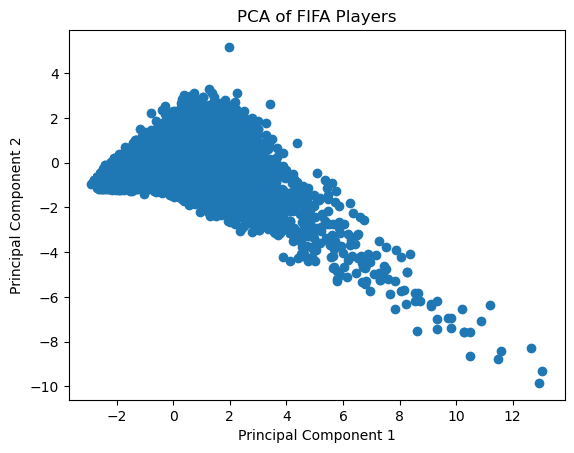

In [11]:
##Visualization

plt.figure()
plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of FIFA Players")
plt.show()